## Informacion importante sobre el dataset

Según la fuente de los datos, las variables numericas que tengan relación con dinero están dadas en billones de pesos. Es importante tener en cuenta esto a la hora de analizar los datos estadísticamente.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga de Datos y revisión general.

In [29]:
ruta = '/content/drive/MyDrive/crecimiento-empresas-colombianas/data/proccesed/proccesed10.000_Empresas_mas_Grandes_del_País_proccesed.csv'
df = pd.read_csv(ruta)
df.head()

,nit,razon_social,supervisor,region,departamento_domicilio,ciudad_domicilio,ciiu,macrosector,ingresos_operacionales,ganancia_perdida,total_activos,total_pasivos,total_patrimonio,ano_de_corte
0,899999068,ECOPETROL S.A.,SUPERFINANCIERA,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,BOGOTA D.C.,610,MINERO,100.59,9.03,198.11,114.35,83.76,2025
1,830095213,ORGANIZACIÓN TERPEL S.A.,SUPERFINANCIERA,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,BOGOTA D.C.,4661,COMERCIO,26.40,0.63,8.11,4.70,3.41,2025
2,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,REGIÓN CARIBE,BOLIVAR,CARTAGENA DE INDIAS,1921,MANUFACTURA,22.40,NaN,34.95,11.57,23.38,2025
3,900276962,D1 S.A.S.,SUPERSOCIEDADES,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,BOGOTA D.C.,4711,COMERCIO,21.61,0.42,6.94,6.72,0.21,2025
4,890904996,EMPRESAS PÚBLICAS DE MEDELLÍN E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,3513,SERVICIOS,20.29,4.88,71.08,36.11,34.97,2025


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   nit                     50000 non-null  int64  
 1   razon_social            50000 non-null  object 
 2   supervisor              50000 non-null  object 
 3   region                  50000 non-null  object 
 4   departamento_domicilio  50000 non-null  object 
 5   ciudad_domicilio        50000 non-null  object 
 6   ciiu                    50000 non-null  int64  
 7   macrosector             50000 non-null  object 
 8   ingresos_operacionales  50000 non-null  float64
 9   ganancia_perdida        49583 non-null  float64
 10  total_activos           50000 non-null  float64
 11  total_pasivos           50000 non-null  float64
 12  total_patrimonio        49829 non-null  float64
 13  ano_de_corte            50000 non-null  int64  
dtypes: float64(5), int64(3), object(6)
mem

## Imputacion de datos para nulos

In [31]:
df = df.fillna(df.mean(numeric_only=True))

In [32]:
df.describe() # variables numéricas


,nit,ciiu,ingresos_operacionales,ganancia_perdida,total_activos,total_pasivos,total_patrimonio,ano_de_corte
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,8.644312e+08,4539.338100,0.171192,0.013653,0.225658,0.116083,0.109932,2023.000000
std,4.069044e+07,2279.776279,1.365192,0.237520,2.416679,1.416051,1.121182,1.414228
min,8.000001e+08,111.000000,0.010000,-3.210000,0.000000,0.000000,-3.690000,2021.000000
25%,8.300111e+08,3110.000000,0.030000,0.000000,0.020000,0.010000,0.010000,2022.000000
50%,8.908070e+08,4659.000000,0.050000,0.000000,0.040000,0.020000,0.010000,2023.000000
75%,9.004234e+08,5612.000000,0.100000,0.010000,0.090000,0.050000,0.040000,2024.000000
max,9.019666e+08,9900.000000,144.820000,33.410000,216.850000,130.540000,91.030000,2025.000000


In [33]:
df.describe(include='object') #Variables

,razon_social,supervisor,region,departamento_domicilio,ciudad_domicilio,macrosector
count,50000,50000,50000,50000,50000,50000
unique,15024,6,10,33,368,6
top,SUMOTO S.A.,SUPERSOCIEDADES,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,BOGOTA D.C.,COMERCIO
freq,10,43750,23444,19755,19755,17335


## Analisis de distribución




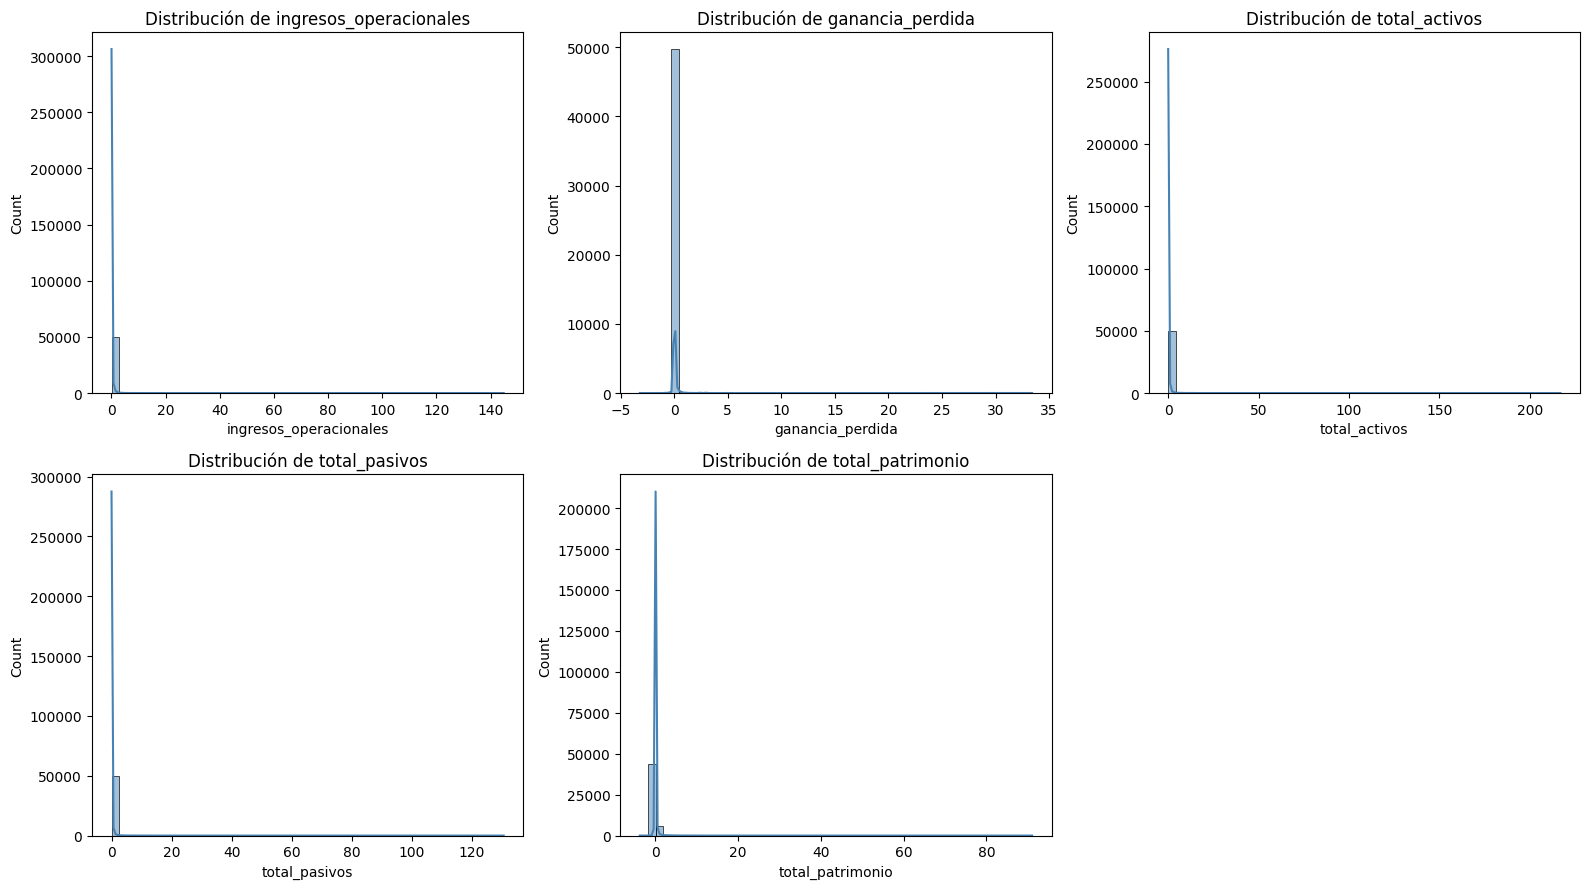

In [34]:
num_cols = [
    "ingresos_operacionales",
    "ganancia_perdida",
    "total_activos",
    "total_pasivos",
    "total_patrimonio",
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribución de {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

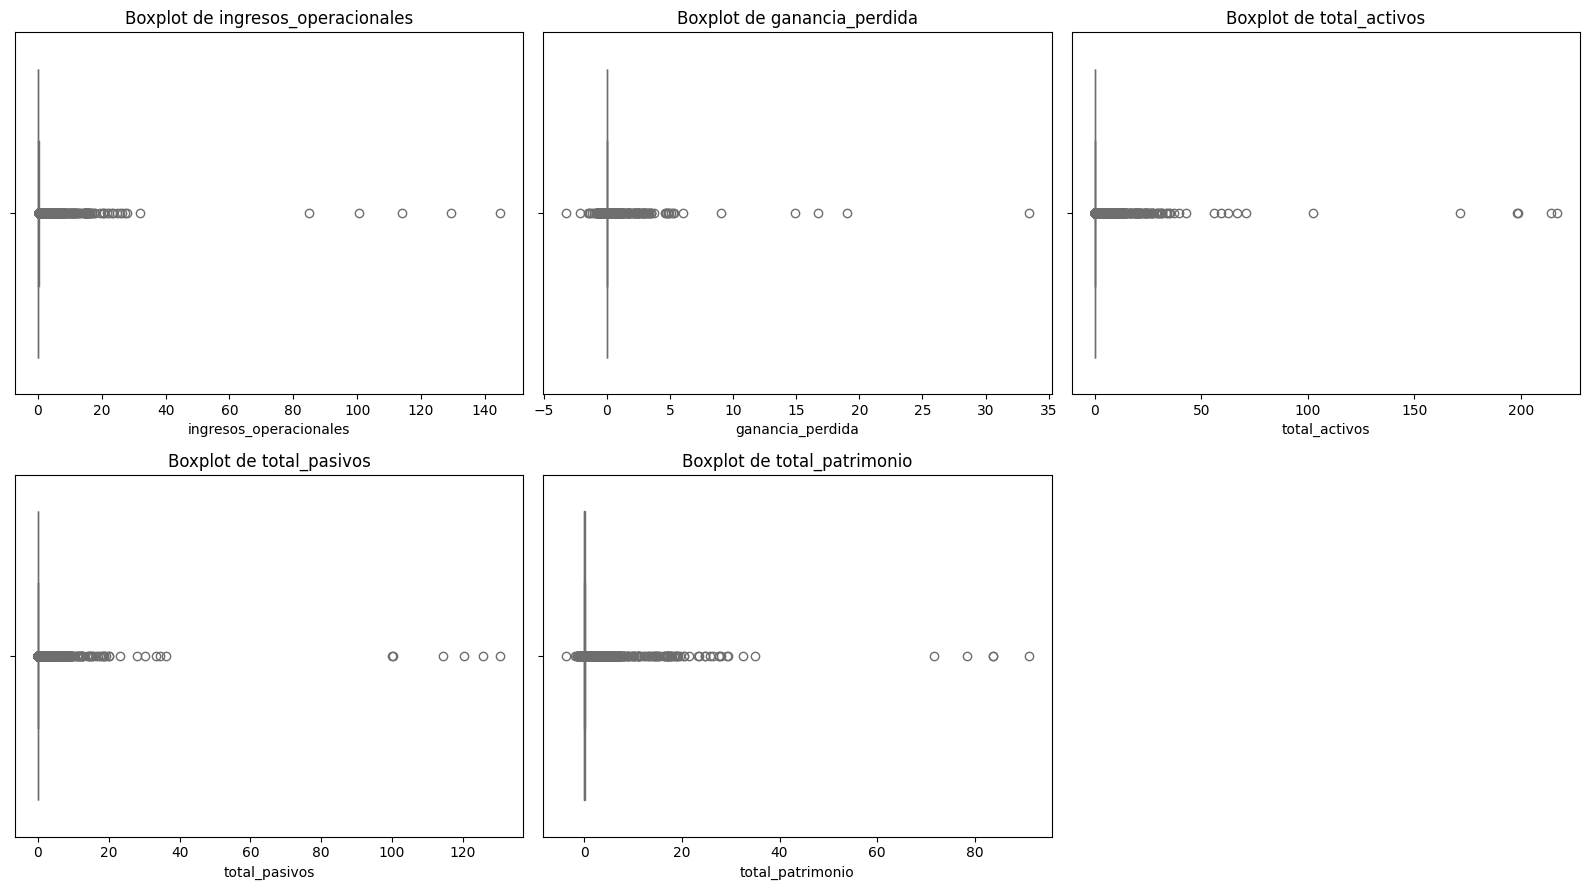

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot de {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


Podemos ver que todas las variables financieras tienen un sesgo fuerte hacia la derecha. Con esto podemos concluir que la mayoría de las empresas del dataset son empresas pequeñas frente a un puñado de gigantes corporativos. En cuanto a ganancia_perdida, la distribución también está centrada cerca de 0 reportan pérdidas en el período. Esto no permite concluir riesgo de quiebra sin analizar tendencia histórica o nivel de endeudamiento, pero sí identifica un segmento minoritario que amerita seguimiento.

##Matriz de correlación

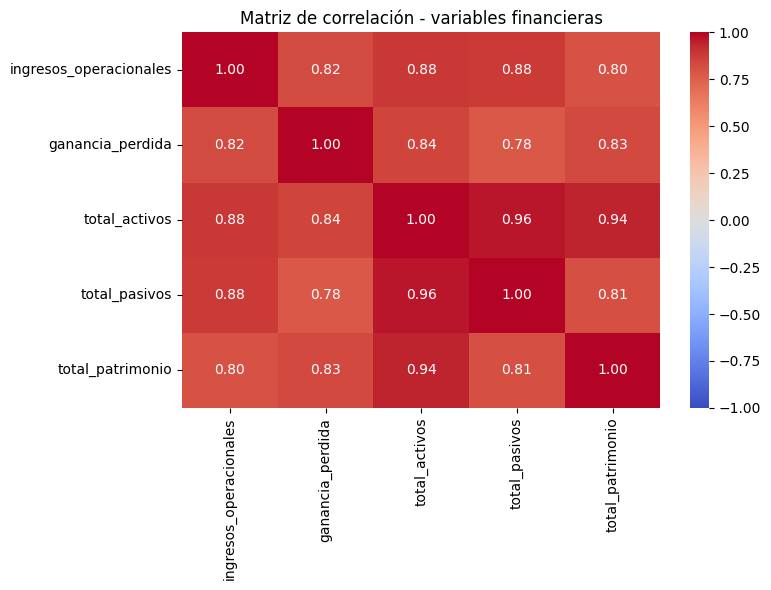

In [36]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación - variables financieras")
plt.tight_layout()
plt.show()


Aquí podemos ver una fuerte relacion entre total activos, total pasivos y patrimonio, lo que es congruente con la teoría económica:

$$\text{Activos} = \text{Pasivos} + \text{Patrimonio}$$

Se debe considerar eliminar patrimonio (y tal vez total activos o total pasivos) para que no afecte en el ejercicio de predicción.

## Conteo de empresas por categoría

Se eliminan del analisis las categorias ciudad_domicilio y departamento_domicilio, ya que presenta redundancia y se deja región que representa bien la ubicación del domicilio.

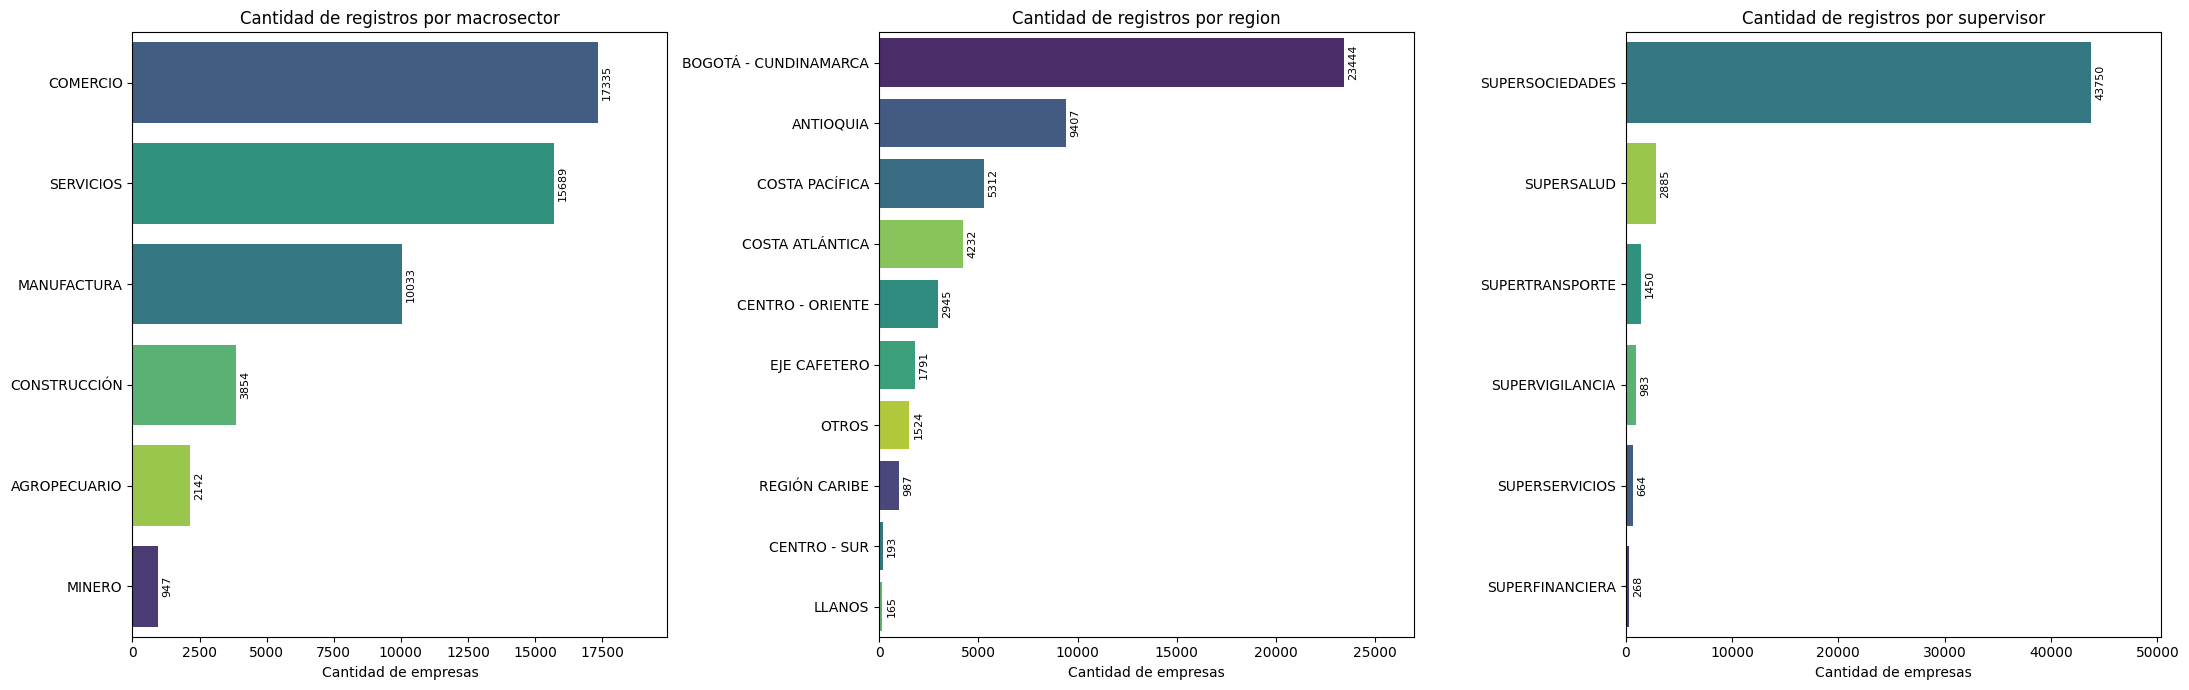

In [37]:

cat_cols = ["macrosector", "region", "supervisor"]
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for i, col in enumerate(cat_cols):
    orden = df[col].value_counts().index
    sns.countplot(y=df[col], order=orden, hue=df[col], legend=False,
                  palette="viridis", ax=axes[i])
    axes[i].set_title(f"Cantidad de registros por {col}")
    axes[i].set_ylabel("")
    axes[i].set_xlabel("Cantidad de empresas")
    for cont in axes[i].containers:
        axes[i].bar_label(cont, fmt="%.0f", padding=3, fontsize=8, rotation=90)
    xmax = df[col].value_counts().max()
    axes[i].set_xlim(0, xmax * 1.15)
plt.subplots_adjust(wspace=0.55)
plt.tight_layout()
plt.show()


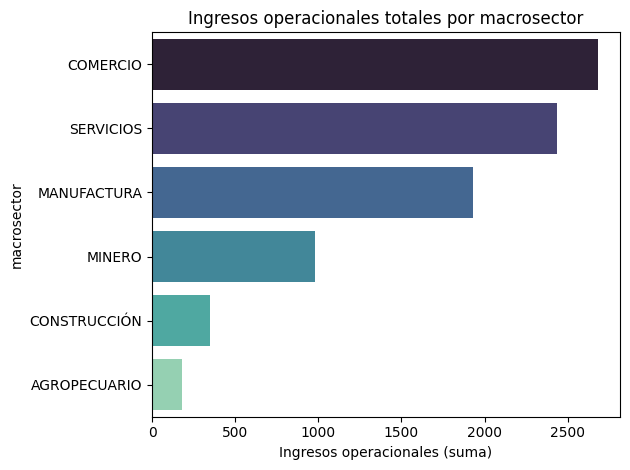

In [38]:
# ------------------------------------------------------------------
# 6. INGRESOS TOTALES POR MACROSECTOR (agregado, no solo conteo)
# Aporta información de negocio: qué sector concentra más ingresos.
# ------------------------------------------------------------------
plt.figure()
ingresos_sector = (
    df.groupby("macrosector")["ingresos_operacionales"]
    .sum()
    .sort_values(ascending=False)
)
sns.barplot(x=ingresos_sector.values, y=ingresos_sector.index,
            hue=ingresos_sector.index, palette="mako", legend=False)
plt.title("Ingresos operacionales totales por macrosector")
plt.xlabel("Ingresos operacionales (suma)")
plt.tight_layout()
plt.show()

Aquí podemos ver algo curioso. Generalmente la distribución de este plot está dado por la cantidad de registros por macrosector mostrado en el plot anterior. Pero el macrosector de la mineria tiene un mayor cantidad de ingresos operacionales respecto a construcción y agropecuario aunque el sector de la mineria tiene menos registros. Esto deja ver que el sector de la mineria parecer generar muy buenos ingresos operacionales.

## Top 15 empresas por ingresos operacionales en 2025


cantidad única de empresas:  15024


/tmp/ipykernel_874/2848764712.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


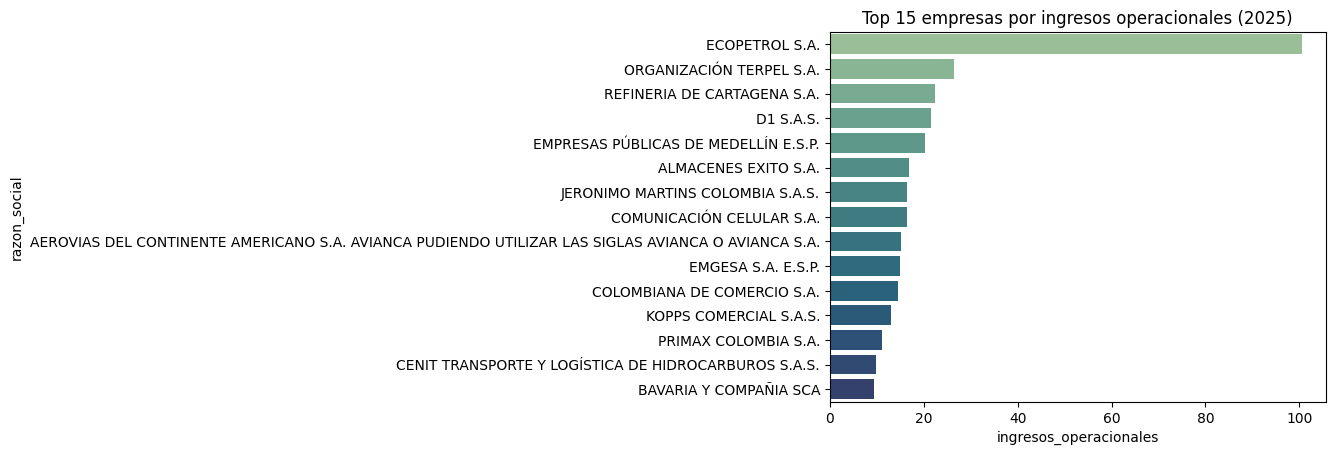

In [39]:
print('cantidad única de empresas: ', df['razon_social'].nunique())
plt.figure()
ultimo_ano = df["ano_de_corte"].max()
top_n = (
    df[df["ano_de_corte"] == ultimo_ano]
    .nlargest(15, "ingresos_operacionales")
)
sns.barplot(x="ingresos_operacionales", y="razon_social", data=top_n,
            hue="razon_social", legend=False, palette="crest")
plt.title(f"Top 15 empresas por ingresos operacionales ({ultimo_ano})")
plt.tight_layout()
plt.show()


Se puede ver como pocas empresas tienen grandes ingresos, lo que confirma el sesgo hacia la derecha que tiene la variable ingesos operacionales. Además, se confirman unas 15024 empresas distintas en el dataset, lo cual indica que no debe ser utilizada en el modelo de predicción.

## Concentración de ganancias cerca a 0

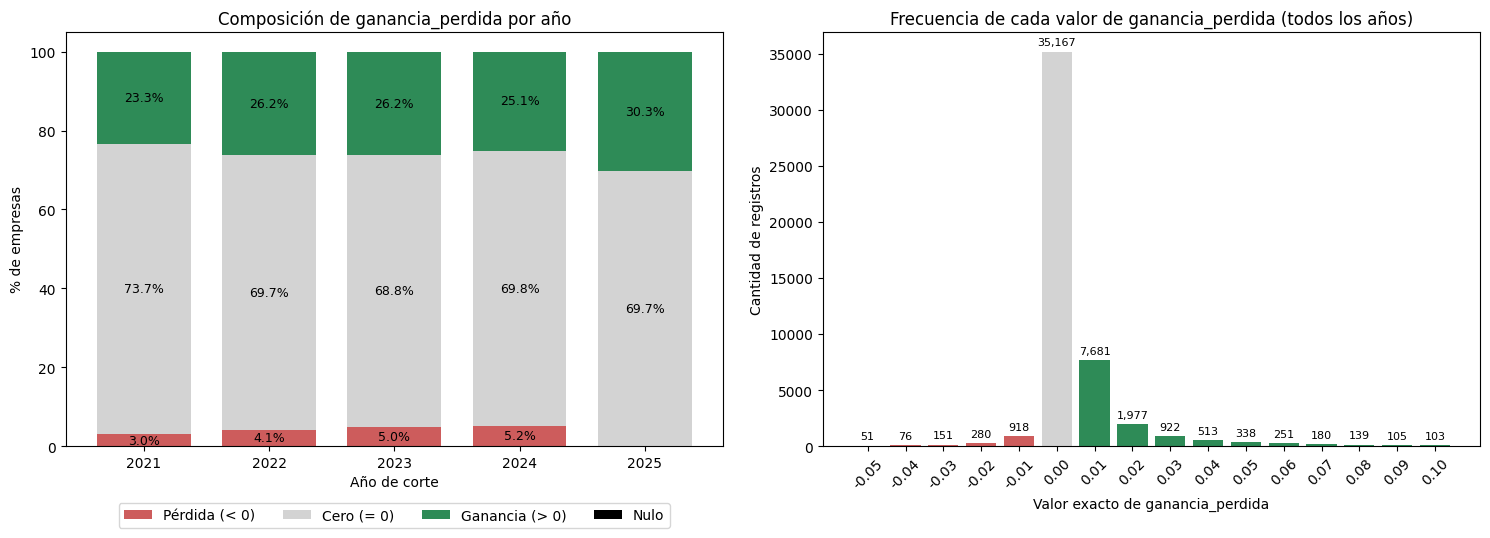

In [40]:

def clasificar(v):
    if pd.isna(v):
        return "Nulo"
    if v < 0:
        return "Pérdida (< 0)"
    if v == 0:
        return "Cero (= 0)"
    return "Ganancia (> 0)"

orden_cat = ["Pérdida (< 0)", "Cero (= 0)", "Ganancia (> 0)", "Nulo"]
colores = {"Pérdida (< 0)": "indianred", "Cero (= 0)": "lightgray",
           "Ganancia (> 0)": "seagreen", "Nulo": "black"}

estado = df["ganancia_perdida"].apply(clasificar)
pct_estado = (
    pd.crosstab(df["ano_de_corte"], estado, normalize="index")
    .reindex(columns=orden_cat, fill_value=0) * 100
)

cerca_cero = df["ganancia_perdida"].round(2)
cerca_cero = cerca_cero[(cerca_cero >= -0.05) & (cerca_cero <= 0.10)]
freq_valores = cerca_cero.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

pct_estado.plot(kind="bar", stacked=True, ax=axes[0],
                color=[colores[c] for c in orden_cat], width=0.75)
axes[0].set_title("Composición de ganancia_perdida por año")
axes[0].set_xlabel("Año de corte")
axes[0].set_ylabel("% de empresas")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
for cont, cat in zip(axes[0].containers, orden_cat):
    etiquetas = [f"{v:.1f}%" if v >= 3 else "" for v in pct_estado[cat]]
    axes[0].bar_label(cont, labels=etiquetas, label_type="center", fontsize=9,
                      color="white" if cat == "Nulo" else "black")

colores_barras = ["indianred" if v < 0 else "lightgray" if v == 0 else "seagreen"
                  for v in freq_valores.index]
axes[1].bar([f"{v:.2f}" for v in freq_valores.index], freq_valores.values,
            color=colores_barras)
axes[1].set_title("Frecuencia de cada valor de ganancia_perdida (todos los años)")
axes[1].set_xlabel("Valor exacto de ganancia_perdida")
axes[1].set_ylabel("Cantidad de registros")
axes[1].tick_params(axis="x", rotation=45)
axes[1].bar_label(axes[1].containers[0], fmt="{:,.0f}", padding=3, fontsize=8)

plt.tight_layout()
plt.show()


Además de que las variables financieras del dataset están dadas en billones de pesos, con esto se puede confirmar que está redondeado a 2 cifras decimales. Lo cual genera cierta perdida de información ya que si una empresa tiene ganancias menores a 0.005 billones de pesos se redondea automaticamente a 0. esto puede ser un problema a la hora de predecir la variable ganancia_perdida ya que el 70% de la variable está en 0.

## Cada predictor vs target.

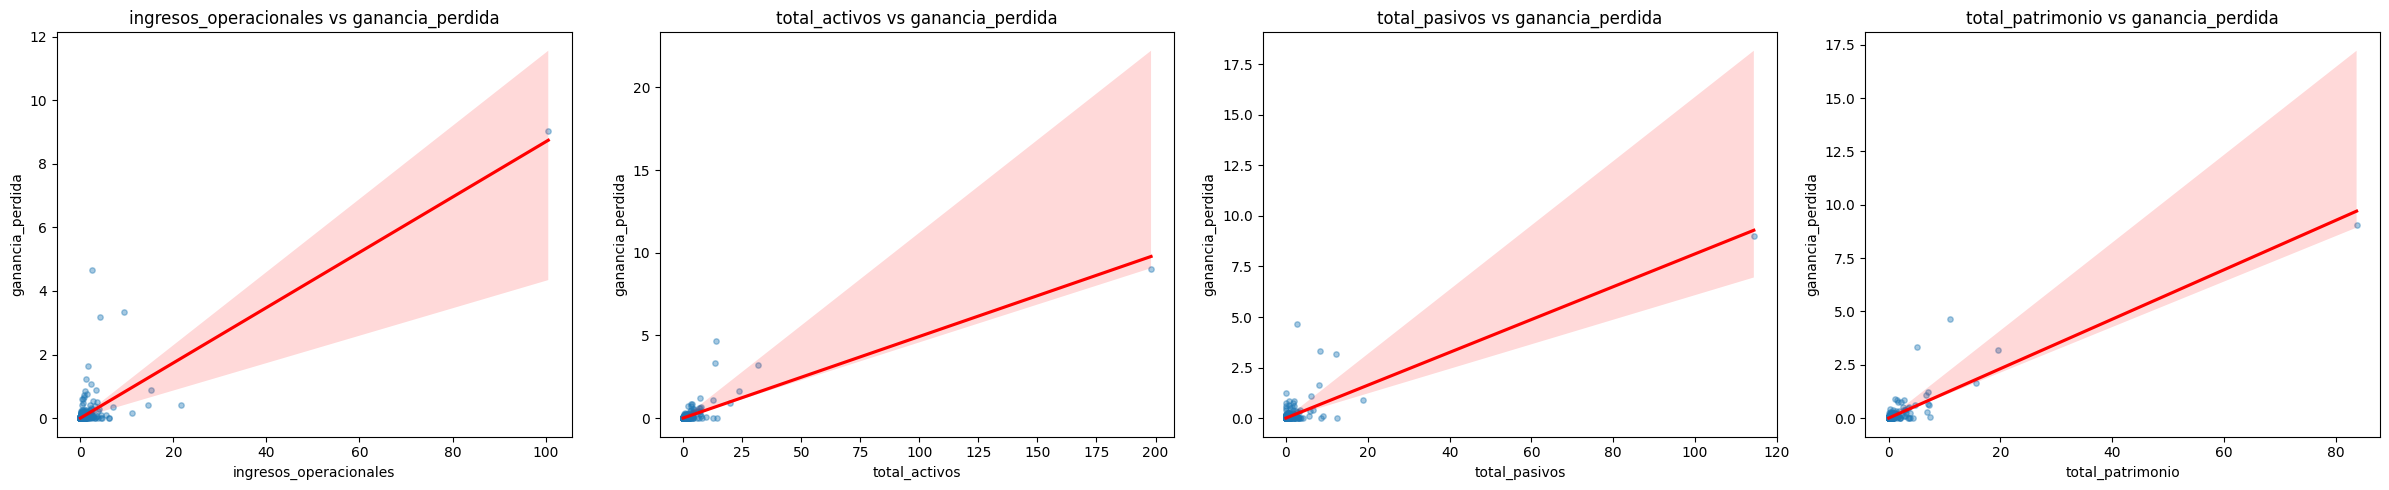

In [41]:
target = "ganancia_perdida"
predictores = [c for c in num_cols if c != target]


df_target = df.dropna(subset=[target]).copy()

fig, axes = plt.subplots(1, len(predictores), figsize=(6 * len(predictores), 5))
muestra_target = df_target[df_target["ano_de_corte"] == ultimo_ano].sample(
    min(3000, len(df_target[df_target["ano_de_corte"] == ultimo_ano])), random_state=42
)
for i, col in enumerate(predictores):
    sns.regplot(
        data=muestra_target, x=col, y=target, ax=axes[i],
        scatter_kws={"alpha": 0.4, "s": 15}, line_kws={"color": "red"}
    )
    axes[i].set_title(f"{col} vs ganancia_perdida")
plt.tight_layout()
plt.show()

Las cuatro variables financieras presentan una relación positiva con ganancia_perdida en 2025, más fuerte con el patrimonio y los activos que con los ingresos y los pasivos. Sin embargo, esta relación está fuertemente influida por Ecopetrol, un punto extremo que aporta los mayores valores en todas las variables: sin él, las correlaciones baja considerablemente de las empresas queda concentrado en la esquina inferior izquierda. Además, la correlación con el patrimonio podría estar inflada mecánicamente, porque la ganancia del período forma parte del patrimonio. Esto sugiere aplicar transformaciones que admitan ceros y negativos o modelos no lineales, y evaluar el modelo con y sin las empresas de mayor tamaño.

## 15. % DE EMPRESAS CON PÉRDIDA VS GANANCIA POR SECTOR

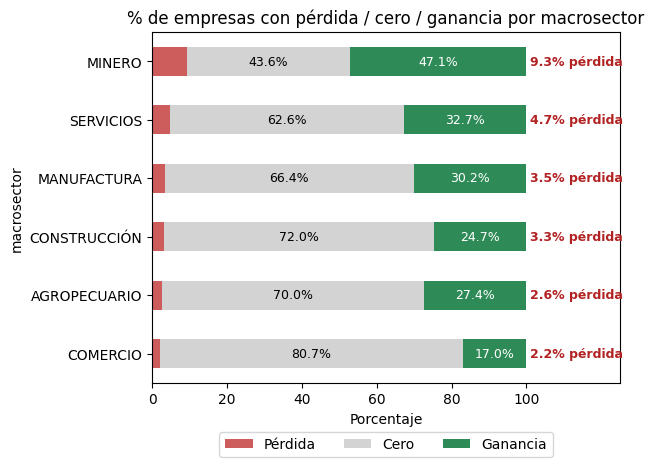

In [45]:
plt.figure()
df_target["resultado"] = np.select(
    [df_target[target] < 0, df_target[target] == 0],
    ["Pérdida", "Cero"],
    default="Ganancia",
)
tabla = (
    df_target.groupby(["macrosector", "resultado"]).size()
    .unstack(fill_value=0)
)
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
tabla_pct = tabla_pct[["Pérdida", "Cero", "Ganancia"]].sort_values("Pérdida", ascending=True)
ax = tabla_pct.plot(kind="barh", stacked=True, ax=plt.gca(),
                    color=["indianred", "lightgray", "seagreen"])
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
for cont, cat in zip(ax.containers, ["Pérdida", "Cero", "Ganancia"]):
    if cat == "Pérdida":
        continue
    ax.bar_label(cont, labels=[f"{v:.1f}%" for v in tabla_pct[cat]],
                 label_type="center", fontsize=9,
                 color="white" if cat == "Ganancia" else "black")
for i, v in enumerate(tabla_pct["Pérdida"]):
    ax.text(101, i, f"{v:.1f}% pérdida", color="firebrick",
            va="center", fontsize=9, fontweight="bold")
ax.set_xlim(0, 125)
ax.set_xticks(range(0, 101, 20))
plt.title("% de empresas con pérdida / cero / ganancia por macrosector")
plt.xlabel("Porcentaje")
plt.tight_layout()

plt.show()

Aquí vemos que el sector de mineria es el que mas ganancia y perdida genera en todo el datset, mientras que en comercio el 80.7% de los registros se queda en 0.